In [1]:
from hossam import load_data
from helpers import *
from pandas import DataFrame
import pandas as pd

import os               # 파일 및 디렉토리 경로를 처리하는 파이썬 내장 모듈
import joblib           # 학습된 모델을 파일로 저장하고 복원하는 직렬화 모듈
import numpy as np      # 수치계산을 위한 파이썬 내장 모듈
import glob as gl       # 파일 목록을 리스트로 반환하는 파이썬 내장 모듈
import datetime as dt   # 날짜 및 시간 처리를 위한 파이썬 내장 모듈

# 훈련, 검증 데이터 분리 함수
from sklearn.model_selection import train_test_split

# 성능평가 지표 계산 함수
from sklearn.metrics import (
    r2_score,                           # 결정계수 (R2)
    mean_absolute_error,                # 평균절대오차 (MAE)
    mean_squared_error,                 # 평균제곱오차 (MSE)
    mean_squared_log_error,             # 평균제곱로그오차 (MSLE)
    mean_absolute_percentage_error      # 평균절대백분율오차 (MAPE)
)

# 선형 계열 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# 비선형 계열 모델
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# 트리계열 모델
from sklearn.tree import DecisionTreeRegressor

# 앙상블 모델
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.29

⚠️  'hossam' 패키지의 최신 버전이 출시되었습니다! (설치된 버전: 0.5.29, 최신 버전: 0.5.33)
   최신 버전으로 업데이트하려면 다음 명령어를 실행하세요:
   pip install --upgrade hossam



In [2]:
# 분석용 데이터 전처리가 완료된 데이터 셋
origin = pd.read_excel("streeteasy_features_log_labeled.xlsx")
df = my_qtcheck.set_type(origin, as_category=["bed_bath_constraint", "typical_prewar", "cluster_name"])

<class 'pandas.DataFrame'>
RangeIndex: 3512 entries, 0 to 3511
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   size_sqft               3512 non-null   float64 
 1   relative_size           3512 non-null   float64 
 2   relative_floor          3512 non-null   float64 
 3   relative_amenity_ratio  3512 non-null   float64 
 4   bed_bath_constraint     3512 non-null   category
 5   typical_prewar          3512 non-null   category
 6   cluster_name            3512 non-null   category
 7   rent                    3512 non-null   float64 
dtypes: category(3), float64(5)
memory usage: 147.7 KB


## 4. 데이터에서 독립변수와 종속변수 분리
### 머신러닝에서는 독립변수를 feature, 종속변수를 target으로 명명한다.

In [3]:
feature = df.drop(columns=["rent"])
target = df["rent"]
feature.shape, target.shape

((3512, 7), (3512,))

## 5. 훈련, 검증 데이터 분리

In [4]:
# 훈련, 검증 데이터 분리
# 분류 문제인 경우 파라미터 추가 --> stratify=target
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((2809, 7), (703, 7), (2809,), (703,))

## 6. 학습을 완료한 모델이 저장될 폴더

In [9]:
project_name = "streeteasy"
base_dir = f"{project_name}/baseline"

if not os.path.exists(base_dir):
    os.makedirs(base_dir)

작업 폴더: streeteasy\baseline
학습 완료 [ 1/11] : linear
학습 완료 [ 2/11] : ridge
학습 완료 [ 3/11] : lasso
학습 완료 [ 4/11] : elasticnet
학습 완료 [ 5/11] : kneighbors
학습 완료 [ 6/11] : svr
학습 완료 [ 7/11] : decisiontree
학습 완료 [ 8/11] : randomforest
학습 완료 [ 9/11] : xgb
학습 완료 [10/11] : lgbm
학습 완료 [11/11] : catboost


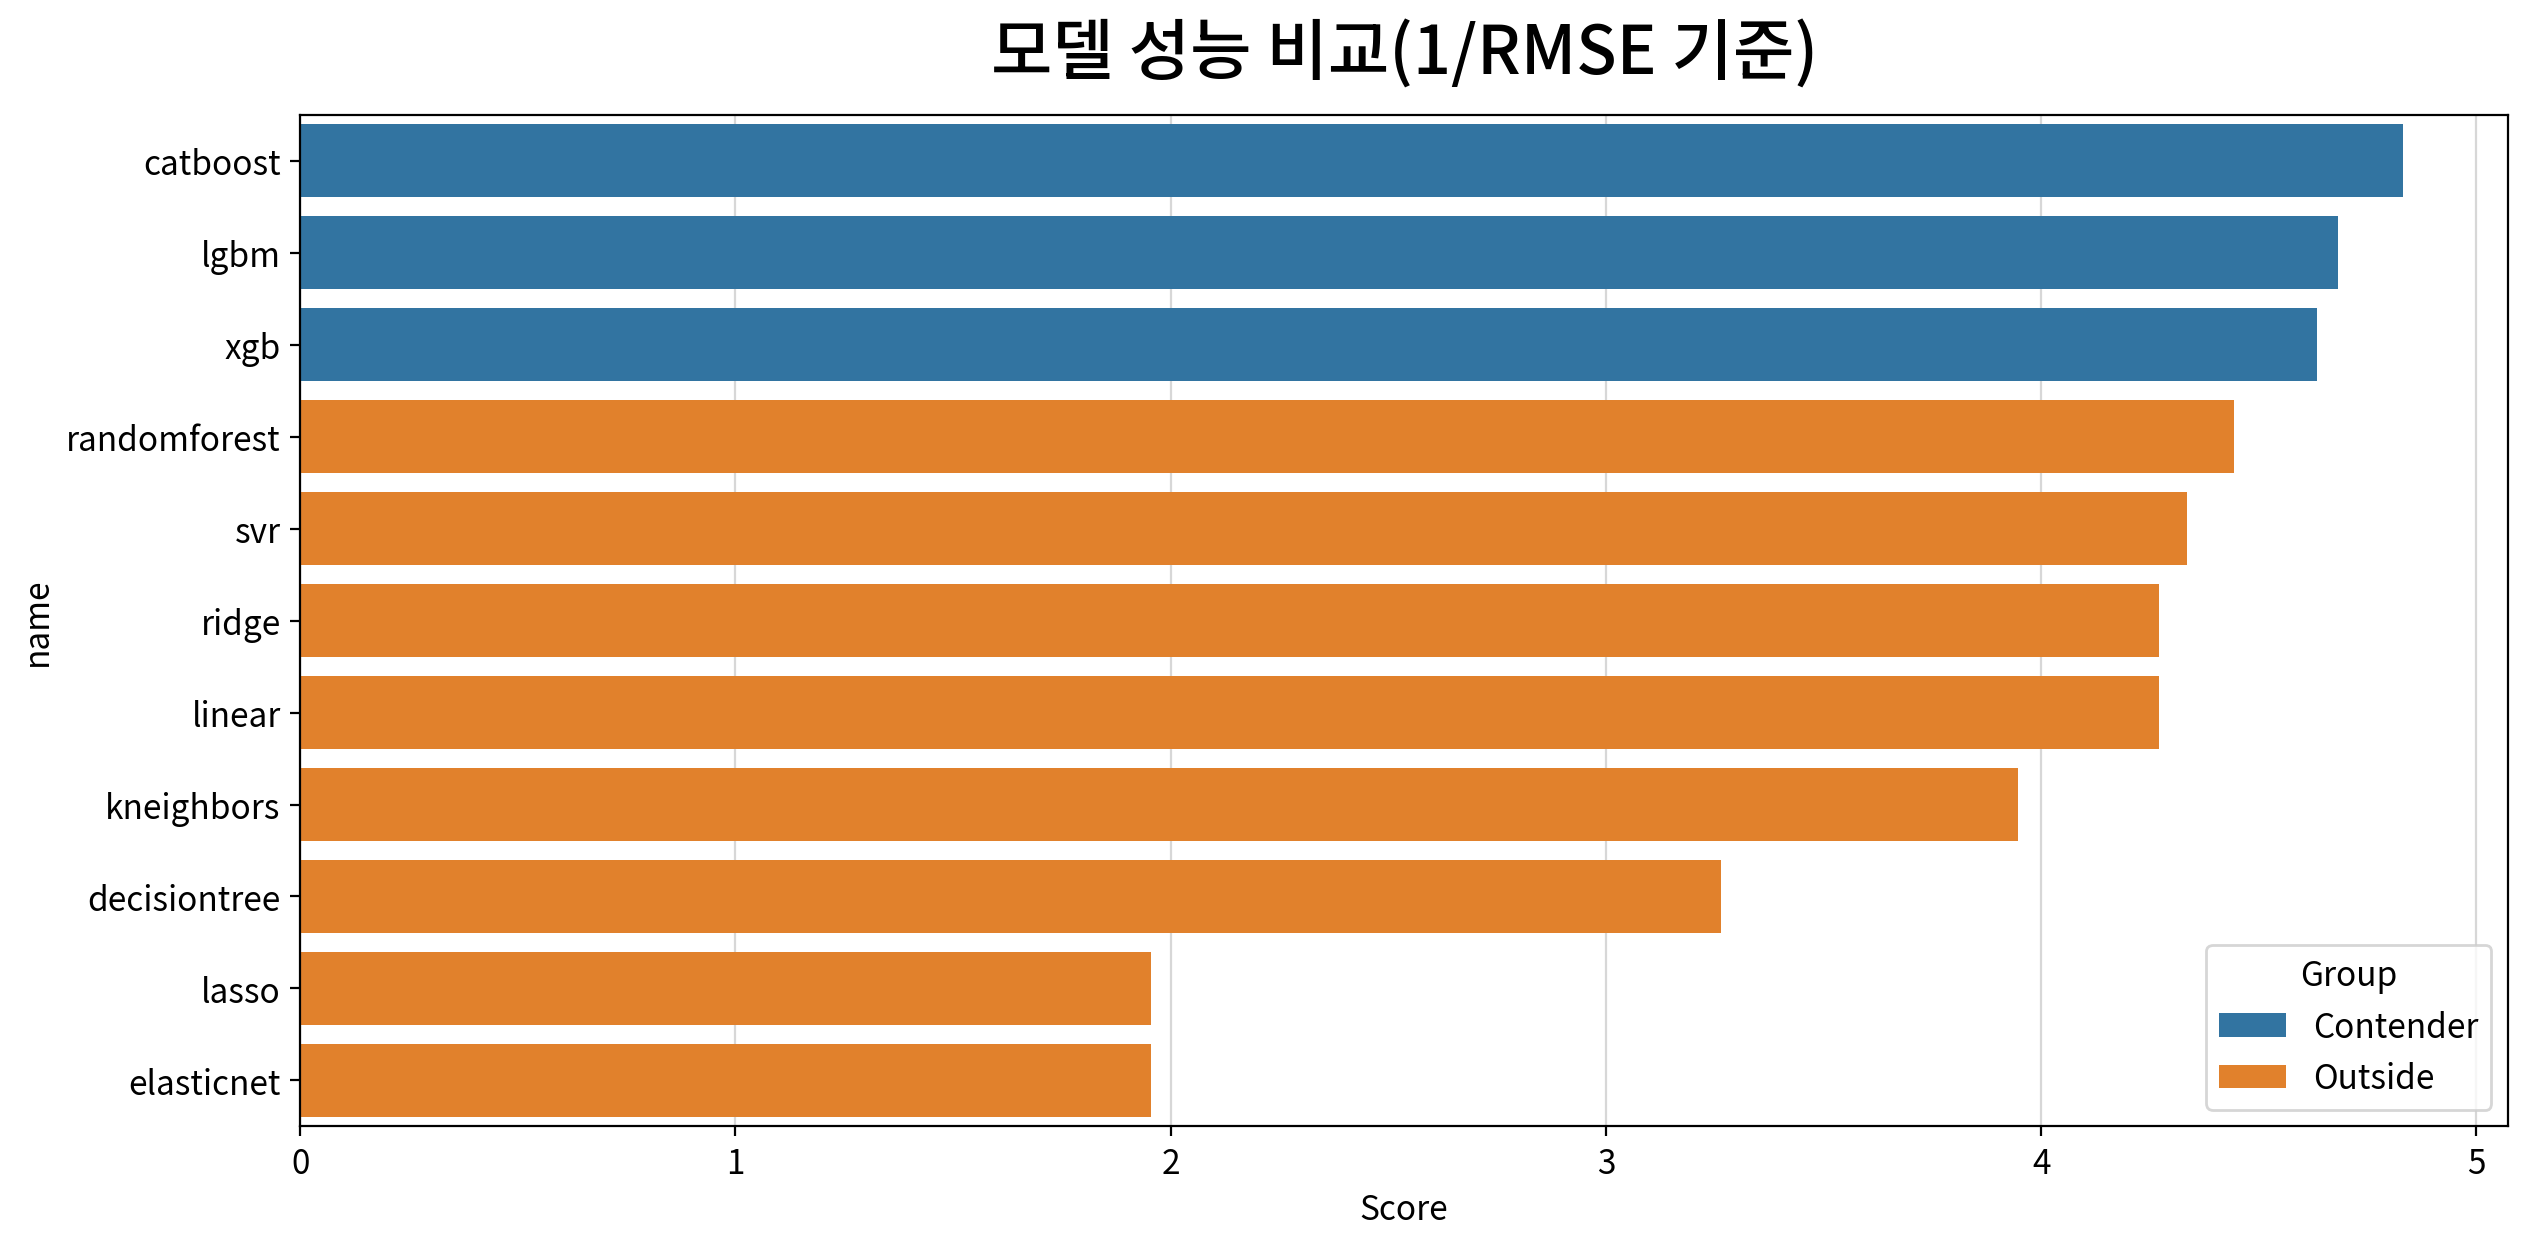


모델 11개 학습·저장 완료 → streeteasy\baseline


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap,Score
name,,,,,,,,,,,,
catboost,1,Contender,CatBoostRegressor,0.836,0.155,0.043,0.207,0.022,0.018,-0.001,0.000,4.831
lgbm,2,Contender,LGBMRegressor,0.826,0.159,0.046,0.214,0.022,0.019,-0.001,0.032,4.682
xgb,3,Contender,XGBRegressor,0.822,0.160,0.047,0.216,0.023,0.019,-0.000,0.042,4.634
randomforest,4,Outside,RandomForestRegressor,0.806,0.168,0.051,0.225,0.024,0.020,-0.001,0.087,4.444
svr,5,Outside,SVR,0.797,0.171,0.053,0.231,0.024,0.020,-0.002,0.114,4.335
ridge,6,Outside,Ridge,0.790,0.178,0.055,0.234,0.025,0.021,-0.001,0.131,4.271
linear,7,Outside,LinearRegression,0.790,0.178,0.055,0.234,0.025,0.021,-0.001,0.131,4.271
kneighbors,8,Outside,KNeighborsRegressor,0.755,0.191,0.064,0.253,0.027,0.023,-0.000,0.224,3.947
decisiontree,9,Outside,DecisionTreeRegressor,0.641,0.225,0.094,0.306,0.032,0.027,-0.002,0.480,3.263


CPU times: total: 1min 39s
Wall time: 13.4 s


In [10]:
%%time
my_ml.reg_baseline("streeteasy", x_train, y_train, x_test, y_test)

## 튜닝 저장폴더 구성

In [11]:
tuned_dir = f"{project_name}/tuned"

if not os.path.exists(tuned_dir):
    os.makedirs(tuned_dir)

In [12]:
# 튜닝하기 원하는 모델을 로드하여 딕셔너리 형태로 저장
models = {
    "linear": my_ml.load_model(f"{base_dir}/linear.pkl"),
    "ridge": my_ml.load_model(f"{base_dir}/ridge.pkl"),
    "lasso": my_ml.load_model(f"{base_dir}/lasso.pkl"),
    "elasticnet": my_ml.load_model(f"{base_dir}/elasticnet.pkl"),
    "kneighbors": my_ml.load_model(f"{base_dir}/kneighbors.pkl"),
    "svr": my_ml.load_model(f"{base_dir}/svr.pkl"),
    "decisiontree": my_ml.load_model(f"{base_dir}/decisiontree.pkl"),
    "randomforest": my_ml.load_model(f"{base_dir}/randomforest.pkl"),
    "xgb": my_ml.load_model(f"{base_dir}/xgb.pkl"),
    "lgbm": my_ml.load_model(f"{base_dir}/lgbm.pkl"),
    "catboost": my_ml.load_model(f"{base_dir}/catboost.pkl")
}

작업 폴더: streeteasy\tuned
탐색 범위: 실무용
탐색 완료 [ 1/11] : linear (0.2초, CV RMSE=0.2465)
    최적 조합: {'model__fit_intercept': True, 'model__positive': False}
탐색 완료 [ 2/11] : ridge (1.0초, CV RMSE=0.2465)
    최적 조합: {'model__alpha': 1.0, 'model__solver': 'lsqr'}
탐색 완료 [ 3/11] : lasso (0.8초, CV RMSE=0.2465)
    최적 조합: {'model__alpha': 0.0001, 'model__max_iter': 1000}
탐색 완료 [ 4/11] : elasticnet (0.8초, CV RMSE=0.2465)
    최적 조합: {'model__alpha': 0.001, 'model__l1_ratio': 0.1}
탐색 완료 [ 5/11] : kneighbors (1.6초, CV RMSE=0.2364)
    최적 조합: {'model__n_neighbors': 20, 'model__p': 2, 'model__weights': 'distance'}
탐색 완료 [ 6/11] : svr (4.3초, CV RMSE=0.2301)
    최적 조합: {'model__C': 1.0, 'model__epsilon': 0.1, 'model__gamma': 0.1}
탐색 완료 [ 7/11] : decisiontree (1.2초, CV RMSE=0.2446)
    최적 조합: {'model__max_depth': 6, 'model__min_samples_leaf': 5}
탐색 완료 [ 8/11] : randomforest (15.8초, CV RMSE=0.2264)
    최적 조합: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}
탐색 완료 [ 9/11] : xgb 

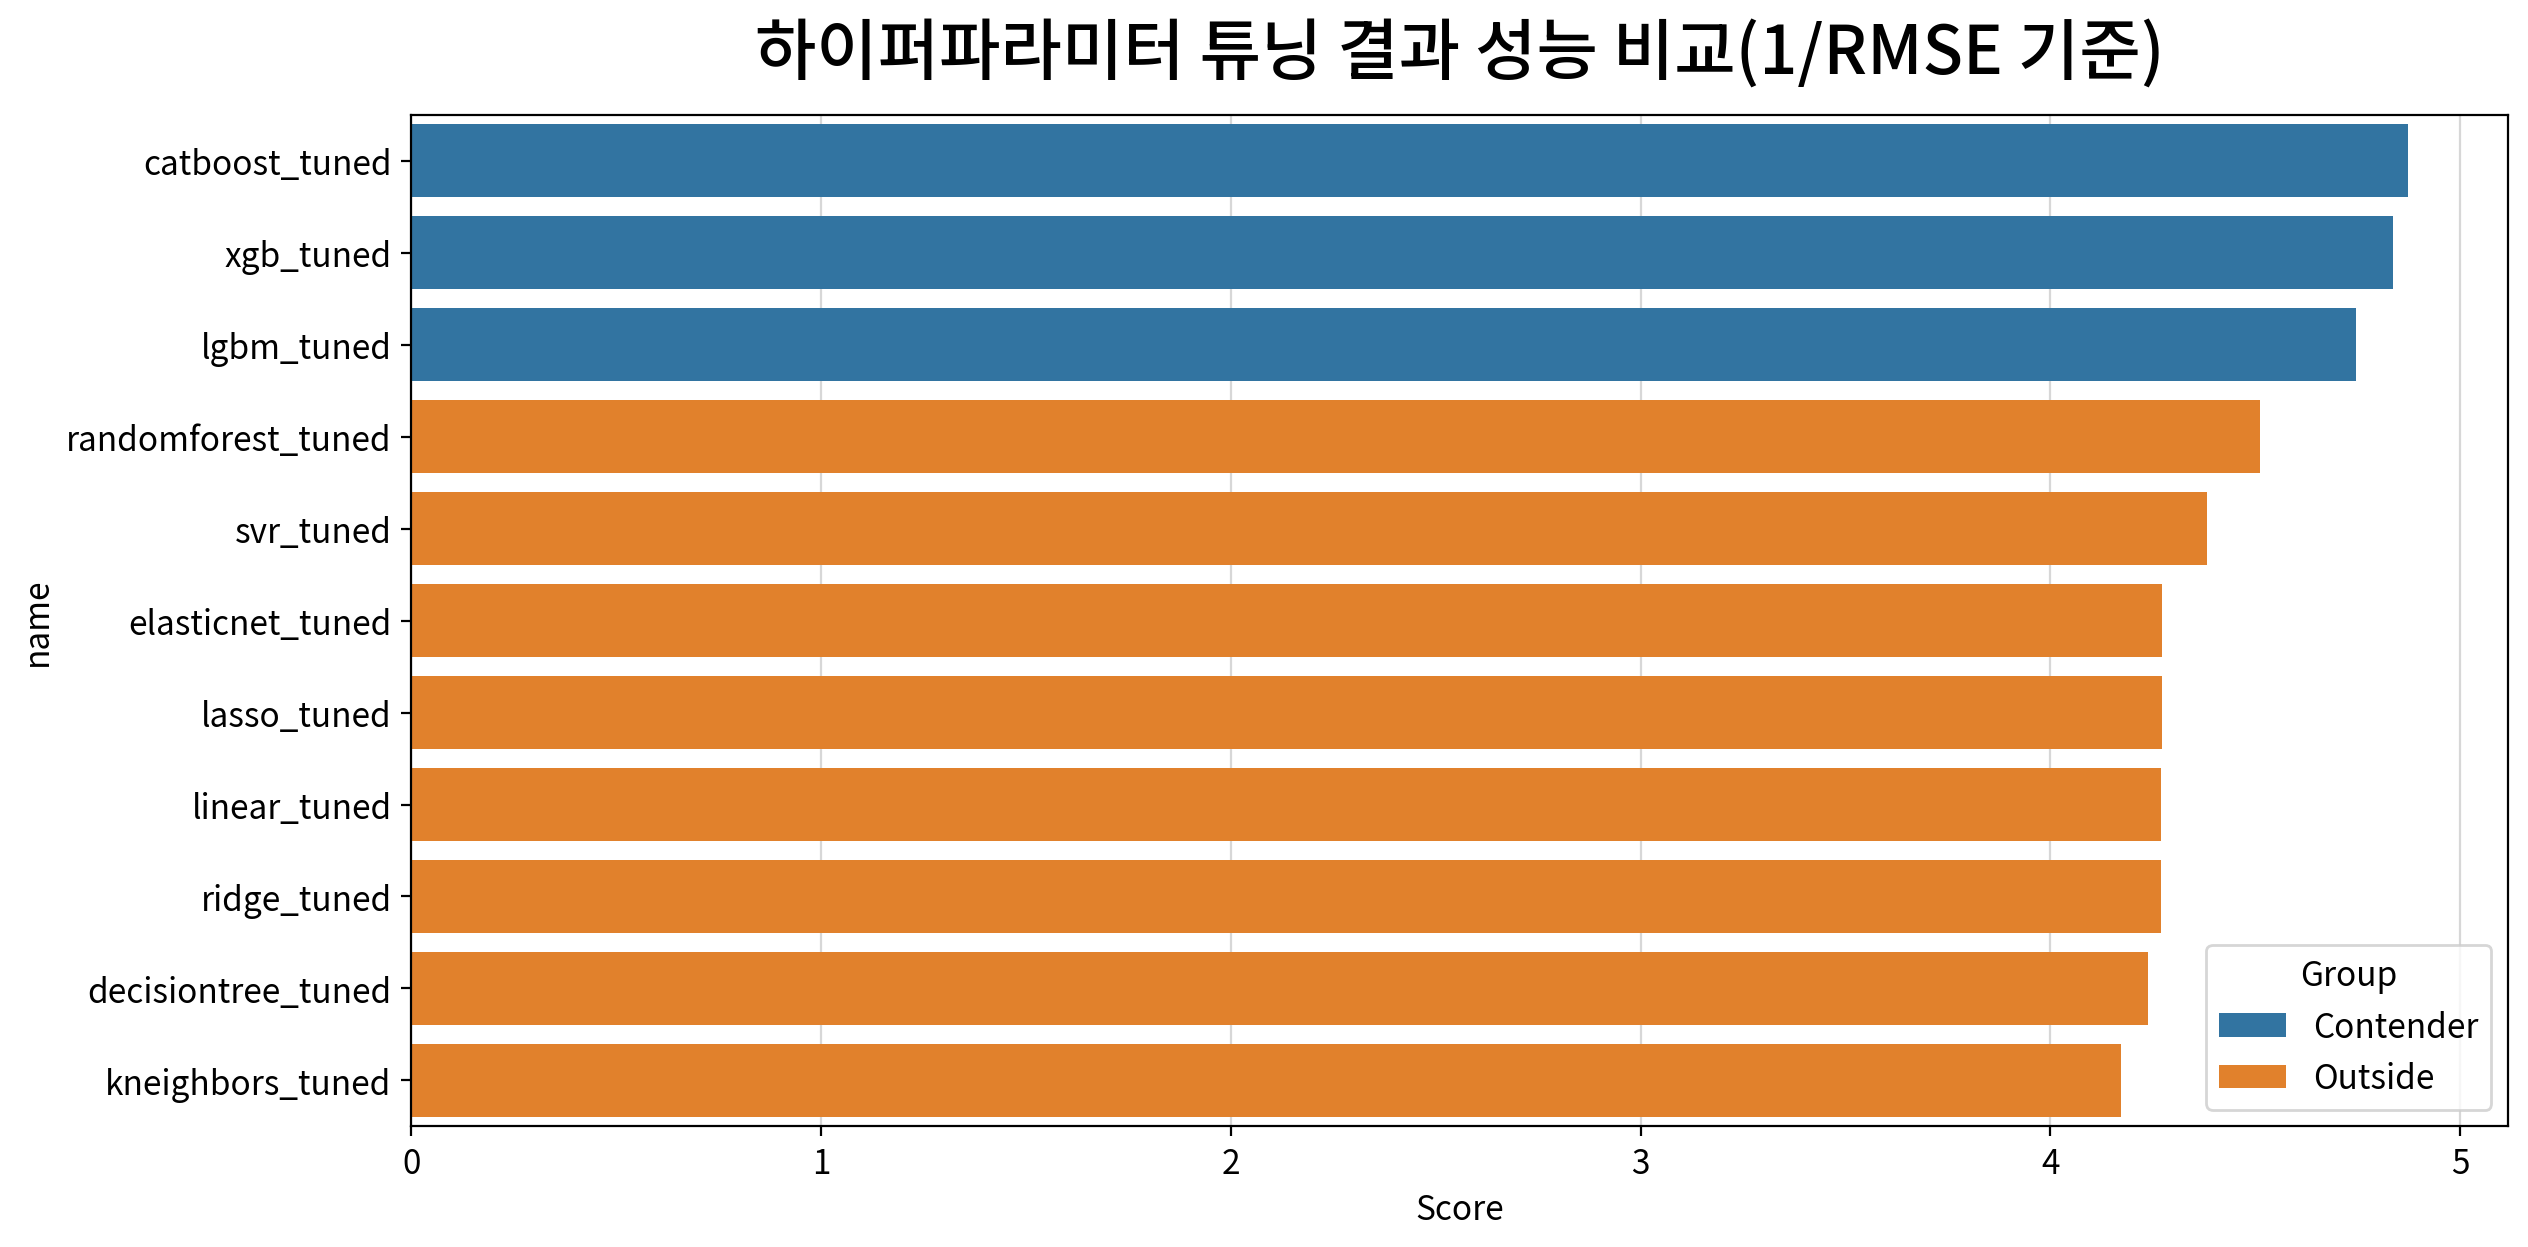


모델 11개 튜닝·저장 완료 → streeteasy\tuned


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap,Score
name,,,,,,,,,,,,
catboost_tuned,1,Contender,CatBoostRegressor,0.839,0.151,0.042,0.205,0.022,0.018,-0.001,0.000,4.873
xgb_tuned,2,Contender,XGBRegressor,0.837,0.154,0.043,0.207,0.022,0.018,-0.001,0.008,4.836
lgbm_tuned,3,Contender,LGBMRegressor,0.830,0.158,0.044,0.211,0.022,0.019,-0.001,0.027,4.747
randomforest_tuned,4,Outside,RandomForestRegressor,0.812,0.165,0.049,0.222,0.023,0.020,-0.001,0.080,4.512
svr_tuned,5,Outside,SVR,0.801,0.168,0.052,0.228,0.024,0.020,-0.002,0.112,4.383
elasticnet_tuned,6,Outside,ElasticNet,0.790,0.178,0.055,0.234,0.025,0.021,-0.001,0.141,4.272
lasso_tuned,7,Outside,Lasso,0.790,0.178,0.055,0.234,0.025,0.021,-0.001,0.141,4.271
linear_tuned,8,Outside,LinearRegression,0.790,0.178,0.055,0.234,0.025,0.021,-0.001,0.141,4.271
ridge_tuned,9,Outside,Ridge,0.790,0.178,0.055,0.234,0.025,0.021,-0.001,0.141,4.271


CPU times: total: 4min 58s
Wall time: 17min 57s


In [13]:
%%time
my_ml.reg_tunes("streeteasy", models, x_train, y_train, x_test, y_test, practice=False)